# Credit Score Default Prediction — Sequential Feature Selection & Model Benchmark

**Objective:** Reduce the "default of credit card clients" dataset from 23 features to the
best 15 features using a three-step sequential pipeline (correlation filter → Information
Value filter → SHAP ranking), track model performance at each stage, and benchmark six
classification algorithms on the final 15-feature set.

**Data leakage control:** a single 70/30 train-test split is created immediately after
loading the data. Every feature-selection step below (correlation, IV, SHAP) and every
hyperparameter search is fit using **only** the training set. The held-out test set is
touched only for scoring.

## 1. Install packages

In [ ]:
!pip install shap scorecardpy xgboost lightgbm catboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


## 2. Imports

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
)

# Feature selection helpers
from sklearn.feature_selection import mutual_info_classif

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

import shap
import scorecardpy as sc
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 3. Load Data

In [ ]:
df = pd.read_excel('/content/default of credit card clients.xlsx',
    header=1
)

# ID is a row identifier, not one of the 23 candidate features — drop it now.
df = df.drop(columns=["ID"])

target = "default payment next month"

print(df.shape)
df.head()

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 4. Exploratory Data Analysis

Data types, missing values, duplicates, and the target distribution.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

Total missing values: 0

Duplicate rows: 35


In [ ]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


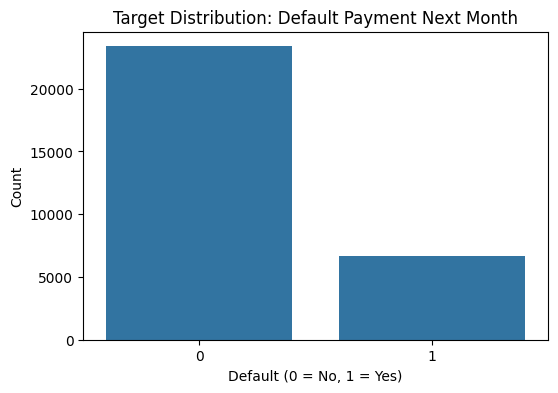

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df)
plt.title("Target Distribution: Default Payment Next Month")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print(df[target].value_counts(normalize=True).rename("proportion"))

The target is imbalanced (roughly 78% non-default / 22% default), which is typical for
credit default data. AUC is an appropriate metric here since it is insensitive to class
imbalance, unlike raw accuracy.

## 5. Train / Test Split (70 / 30)

This split is created **before** any feature selection. All correlation, IV, and SHAP
calculations below use `X_train` / `y_train` only. `X_test` / `y_test` are held out and
used purely for scoring, so the same test set is used to evaluate every stage — making the
stage-wise AUC numbers directly comparable.

In [ ]:
X_full = df.drop(columns=[target])
y_full = df[target]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_full
)

print("Train shape:", X_train_full.shape)
print("Test shape :", X_test_full.shape)
print("Starting feature count:", X_train_full.shape[1])

Train shape: (21000, 23)
Test shape : (9000, 23)
Starting feature count: 23


In [ ]:
def evaluate_lightgbm(X_train, y_train, X_test, y_test, model_name, verbose=True):
    """Train a LightGBM classifier on the given feature set and score it on the fixed
    held-out test set. Returns (fitted_model, train_auc, test_auc)."""
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    model.fit(X_train, y_train)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = model.predict(X_test)

    train_auc = roc_auc_score(y_train, train_prob)
    test_auc = roc_auc_score(y_test, test_prob)

    if verbose:
        print("=" * 60)
        print(model_name)
        print("=" * 60)
        print("Train AUC :", train_auc)
        print("Test AUC  :", test_auc)
        print("Accuracy  :", accuracy_score(y_test, test_pred))
        print("Precision :", precision_score(y_test, test_pred))
        print("Recall    :", recall_score(y_test, test_pred))
        print("F1-score  :", f1_score(y_test, test_pred))
        print("\nConfusion Matrix")
        print(confusion_matrix(y_test, test_pred))

    return model, train_auc, test_auc


stage_results = []  # collects (stage_label, n_features, train_auc, test_auc)

model_23, train_auc_23, test_auc_23 = evaluate_lightgbm(
    X_train_full, y_train, X_test_full, y_test, "Baseline — All 23 Features"
)
stage_results.append(("23 (baseline)", X_train_full.shape[1], train_auc_23, test_auc_23))

Baseline — All 23 Features
Train AUC : 0.918352992126062
Test AUC  : 0.7750462399674266
Accuracy  : 0.8162222222222222
Precision : 0.6567441860465116
Recall    : 0.3545956805625314
F1-score  : 0.46053489889106325

Confusion Matrix
[[6640  369]
 [1285  706]]


## 6. Step A — Correlation Filter (Remove Highly Correlated Features)

For each pair of features with |Pearson correlation| > 0.8, we keep the feature with the
higher **mutual information with the target** and drop the other. Mutual information is
used (rather than the raw target-correlation) because it captures non-linear associations,
which better reflects how a tree-based model like LightGBM will actually use the feature —
this is the predictive-power metric the assignment invites ("e.g., AUC or Mutual
Information"). All of this is computed on `X_train_full` only.

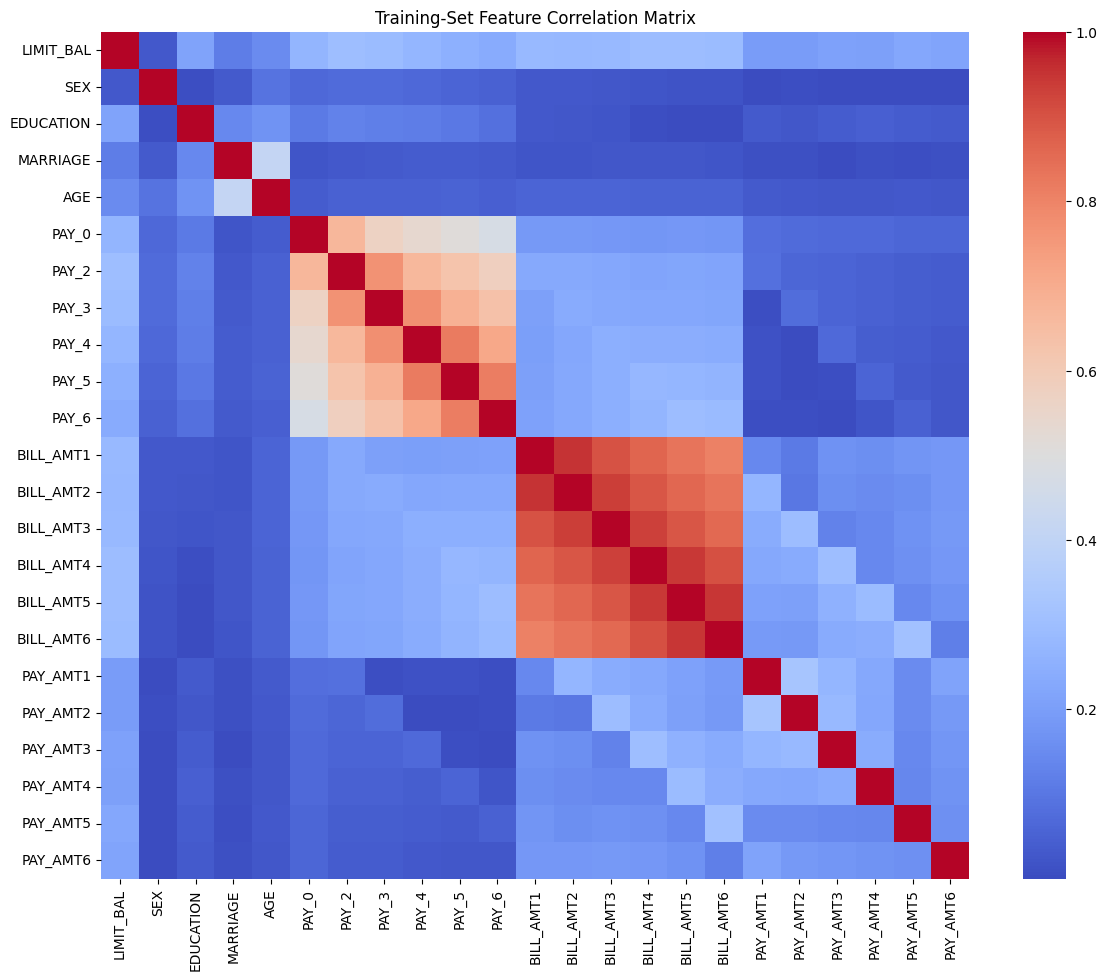

Found 17 feature pairs with |corr| > 0.8:
  PAY_4 - PAY_5: 0.82
  PAY_5 - PAY_6: 0.81
  BILL_AMT1 - BILL_AMT2: 0.95
  BILL_AMT1 - BILL_AMT3: 0.90
  BILL_AMT2 - BILL_AMT3: 0.94
  BILL_AMT1 - BILL_AMT4: 0.86
  BILL_AMT2 - BILL_AMT4: 0.89
  BILL_AMT3 - BILL_AMT4: 0.93
  BILL_AMT1 - BILL_AMT5: 0.83
  BILL_AMT2 - BILL_AMT5: 0.86
  BILL_AMT3 - BILL_AMT5: 0.89
  BILL_AMT4 - BILL_AMT5: 0.94
  BILL_AMT1 - BILL_AMT6: 0.81
  BILL_AMT2 - BILL_AMT6: 0.83
  BILL_AMT3 - BILL_AMT6: 0.86
  BILL_AMT4 - BILL_AMT6: 0.90
  BILL_AMT5 - BILL_AMT6: 0.95


In [ ]:
corr_matrix = X_train_full.corr(numeric_only=True).abs()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0.5)
plt.title("Training-Set Feature Correlation Matrix")
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.8
]

print(f"Found {len(high_corr_pairs)} feature pairs with |corr| > 0.8:")
for f1, f2, c in high_corr_pairs:
    print(f"  {f1} - {f2}: {c:.2f}")

In [ ]:
# Predictive power: mutual information with the target, computed on the training set
mi_scores = pd.Series(
    mutual_info_classif(X_train_full, y_train, random_state=RANDOM_STATE),
    index=X_train_full.columns
)

to_drop = set()
for f1, f2, _ in high_corr_pairs:
    weaker = f1 if mi_scores[f1] < mi_scores[f2] else f2
    to_drop.add(weaker)

to_drop = sorted(to_drop)
print("Features removed by the correlation filter:")
print(to_drop)
print("Number removed:", len(to_drop))
print("Feature count after Step A:", X_train_full.shape[1] - len(to_drop))

Features removed by the correlation filter:
['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_4', 'PAY_6']
Number removed: 7
Feature count after Step A: 16


In [ ]:
X_train_A = X_train_full.drop(columns=to_drop)
X_test_A = X_test_full.drop(columns=to_drop)

model_A, train_auc_A, test_auc_A = evaluate_lightgbm(
    X_train_A, y_train, X_test_A, y_test, "After Step A — Correlation Filter"
)
stage_results.append(("After Step A", X_train_A.shape[1], train_auc_A, test_auc_A))

After Step A — Correlation Filter
Train AUC : 0.9117415431760135
Test AUC  : 0.7725344374983474
Accuracy  : 0.8172222222222222
Precision : 0.6619850187265918
Recall    : 0.35509794073329987
F1-score  : 0.4622425629290618

Confusion Matrix
[[6648  361]
 [1284  707]]


## 7. Step B — Information Value (IV) Filter

IV is calculated on the training set only. Per the assignment, we strictly drop any
feature with **IV <= 0.0** (note this is stricter than the conventional "useless below
0.02" rule of thumb — we follow the assignment's instruction here).

In [ ]:
iv_input = X_train_A.copy()
iv_input[target] = y_train.values

iv_table = sc.iv(iv_input, y=target).sort_values(by="info_value", ascending=False)
print(iv_table)

     variable  info_value
9       PAY_0    0.899114
15      PAY_2    0.560190
13      PAY_3    0.421926
1       PAY_5    0.346351
3    PAY_AMT6    0.341964
5    PAY_AMT4    0.340819
11   PAY_AMT5    0.339537
2    PAY_AMT1    0.337573
12   PAY_AMT3    0.328751
7    PAY_AMT2    0.322877
10  LIMIT_BAL    0.218271
6   BILL_AMT1    0.134521
0   EDUCATION    0.036337
14        AGE    0.030534
8         SEX    0.010423
4    MARRIAGE    0.006891


In [ ]:
low_iv_features = iv_table.loc[iv_table["info_value"] <= 0.0, "variable"].tolist()

print("Features removed by the IV filter (IV <= 0.0):")
print(low_iv_features)
print("Number removed:", len(low_iv_features))
print("Feature count after Step B:", X_train_A.shape[1] - len(low_iv_features))

Features removed by the IV filter (IV <= 0.0):
[]
Number removed: 0
Feature count after Step B: 16


In [ ]:
X_train_B = X_train_A.drop(columns=low_iv_features)
X_test_B = X_test_A.drop(columns=low_iv_features)

model_B, train_auc_B, test_auc_B = evaluate_lightgbm(
    X_train_B, y_train, X_test_B, y_test, "After Step B — IV Filter"
)
stage_results.append(("After Step B", X_train_B.shape[1], train_auc_B, test_auc_B))

After Step B — IV Filter
Train AUC : 0.9117415431760135
Test AUC  : 0.7725344374983474
Accuracy  : 0.8172222222222222
Precision : 0.6619850187265918
Recall    : 0.35509794073329987
F1-score  : 0.4622425629290618

Confusion Matrix
[[6648  361]
 [1284  707]]


## 8. Step C — SHAP Value Ranking (Select Top 15)

A LightGBM model is trained on the Step-B training features, SHAP values are computed
**on the training set**, and the top 15 features are selected by mean absolute SHAP
value. Using the training set (not the test set) for the ranking keeps the test set
completely unseen until final scoring.

In [ ]:
explainer = shap.TreeExplainer(model_B)
shap_values = explainer.shap_values(X_train_B)

if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive class

shap_importance = pd.DataFrame({
    "Feature": X_train_B.columns,
    "SHAP Importance": np.abs(shap_values).mean(axis=0)
}).sort_values(by="SHAP Importance", ascending=False)

print(shap_importance)

      Feature  SHAP Importance
5       PAY_0         0.505213
0   LIMIT_BAL         0.222050
9   BILL_AMT1         0.182061
12   PAY_AMT3         0.148212
10   PAY_AMT1         0.120159
11   PAY_AMT2         0.116072
8       PAY_5         0.107030
7       PAY_3         0.100797
6       PAY_2         0.083597
15   PAY_AMT6         0.078821
14   PAY_AMT5         0.068738
13   PAY_AMT4         0.065575
3    MARRIAGE         0.060787
4         AGE         0.052812
2   EDUCATION         0.041951
1         SEX         0.031304


In [ ]:
print("Dropped by Step C:", shap_importance.iloc[15:]["Feature"].tolist())

Dropped by Step C: ['SEX']


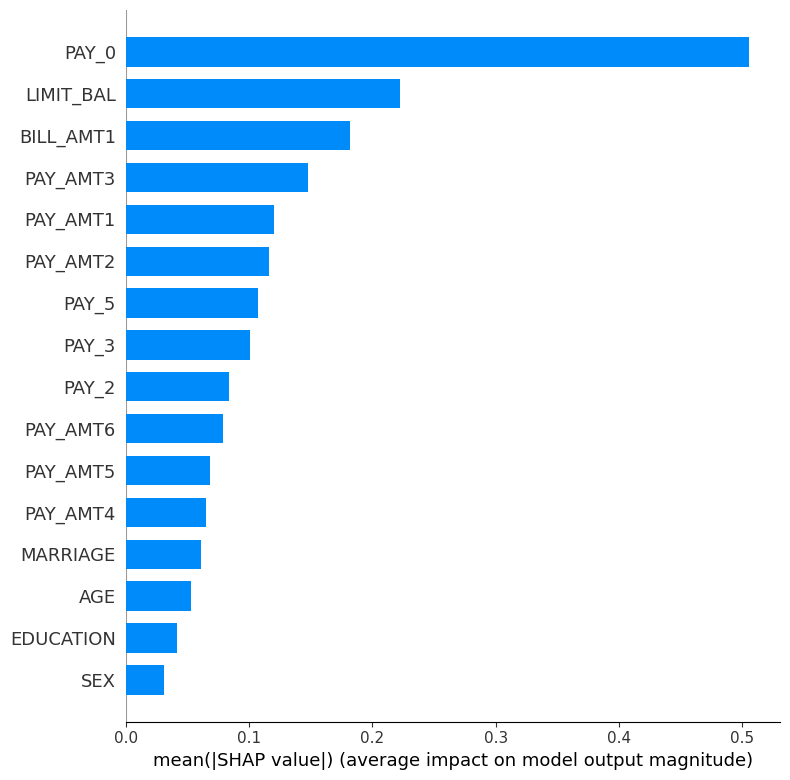

In [ ]:
shap.summary_plot(shap_values, X_train_B, plot_type="bar")

In [ ]:
TOP_N = 15
selected_features = shap_importance.head(TOP_N)["Feature"].tolist()

print("Top 15 selected features:")
print(selected_features)

X_train_15 = X_train_B[selected_features]
X_test_15 = X_test_B[selected_features]

print("\nFinal training shape:", X_train_15.shape)
print("Final test shape    :", X_test_15.shape)

Top 15 selected features:
['PAY_0', 'LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT3', 'PAY_AMT1', 'PAY_AMT2', 'PAY_5', 'PAY_3', 'PAY_2', 'PAY_AMT6', 'PAY_AMT5', 'PAY_AMT4', 'MARRIAGE', 'AGE', 'EDUCATION']

Final training shape: (21000, 15)
Final test shape    : (9000, 15)


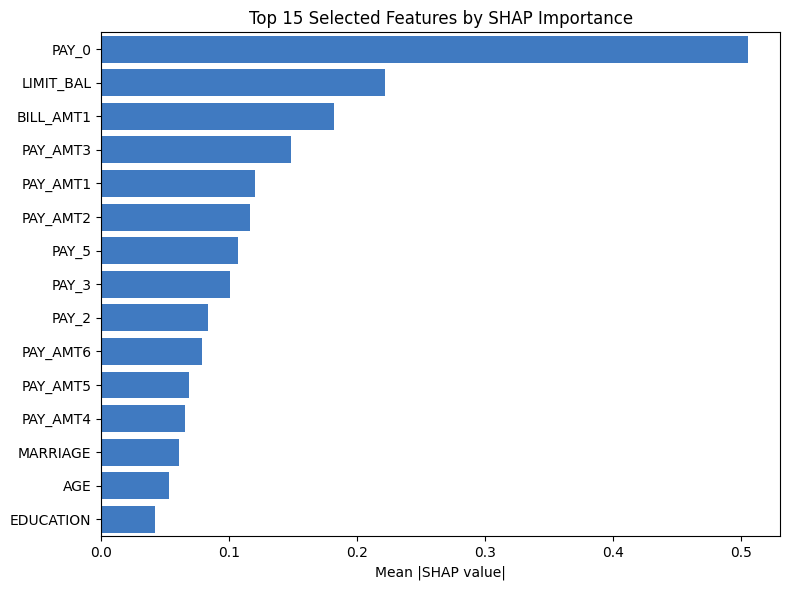

In [ ]:
plt.figure(figsize=(8, 6))

top15_importance = shap_importance.head(TOP_N)

sns.barplot(
    data=top15_importance,
    x="SHAP Importance",
    y="Feature",
    color="#2a78d6"
)

plt.title("Top 15 Selected Features by SHAP Importance")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("")
plt.tight_layout()
plt.show()

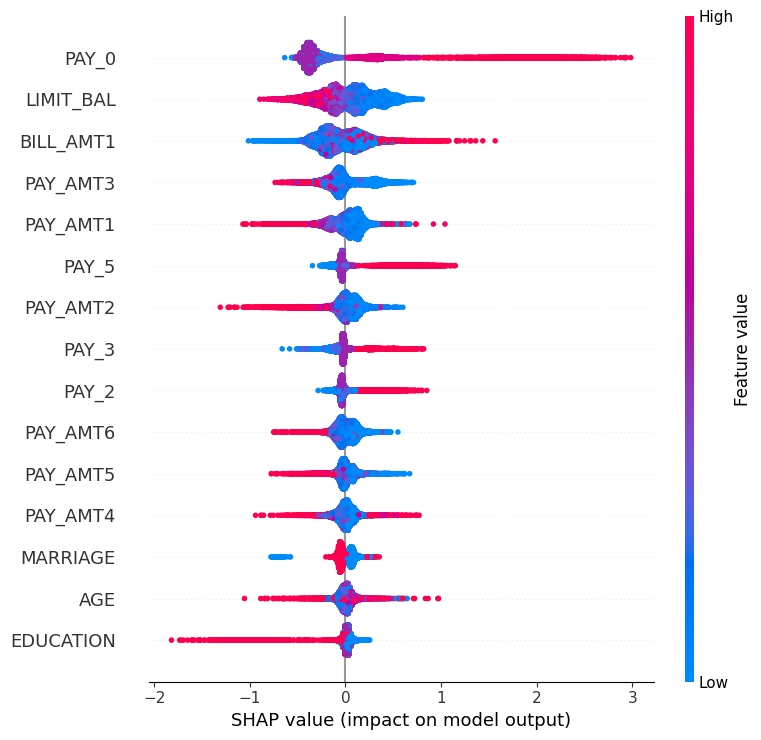

In [ ]:
explainer_15 = shap.TreeExplainer(model_15)
shap_values_15 = explainer_15.shap_values(X_train_15)

if isinstance(shap_values_15, list):
    shap_values_15 = shap_values_15[1]  # positive class

shap.summary_plot(shap_values_15, X_train_15)

In [ ]:
model_15, train_auc_15, test_auc_15 = evaluate_lightgbm(
    X_train_15, y_train, X_test_15, y_test, "After Step C — Top 15 SHAP Features"
)
stage_results.append(("15 (After Step C)", X_train_15.shape[1], train_auc_15, test_auc_15))

After Step C — Top 15 SHAP Features
Train AUC : 0.9105411781585839
Test AUC  : 0.7742657266588219
Accuracy  : 0.8185555555555556
Precision : 0.6688679245283019
Recall    : 0.3561024610748368
F1-score  : 0.46476565060635855

Confusion Matrix
[[6658  351]
 [1282  709]]


## 9. Stage-Wise Performance Summary (23 → A → B → 15)

In [ ]:
stage_df = pd.DataFrame(
    stage_results,
    columns=["Stage", "Num Features", "Train AUC", "Test AUC"]
)
stage_df

,Stage,Num Features,Train AUC,Test AUC
0,23 (baseline),23,0.918353,0.775046
1,After Step A,16,0.911742,0.772534
2,After Step B,16,0.911742,0.772534
3,15 (After Step C),15,0.910541,0.774266


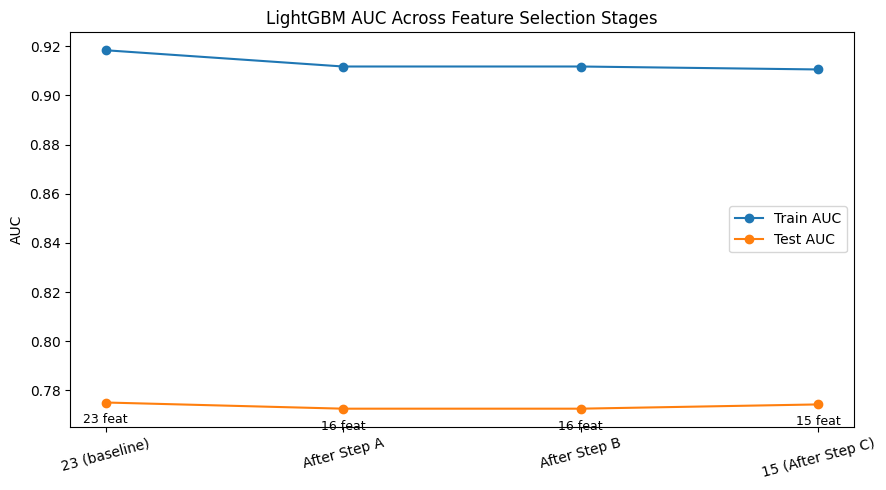

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(stage_df["Stage"], stage_df["Train AUC"], marker="o", label="Train AUC")
ax.plot(stage_df["Stage"], stage_df["Test AUC"], marker="o", label="Test AUC")
for i, row in stage_df.iterrows():
    ax.annotate(f'{row["Num Features"]} feat', (i, row["Test AUC"]),
                textcoords="offset points", xytext=(0, -15), ha="center", fontsize=9)
ax.set_ylabel("AUC")
ax.set_title("LightGBM AUC Across Feature Selection Stages")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 10. Final Model Comparison (15 Features)

Six algorithms are tuned with `RandomizedSearchCV` (3-fold CV, scoring = ROC AUC) on
`X_train_15` / `y_train`, then evaluated once on the untouched `X_test_15` / `y_test`.

> `RandomizedSearchCV` is used instead of an exhaustive `GridSearchCV` to keep runtime
> reasonable on 30k rows / 6 models; swap in `GridSearchCV` with the same param grids if
> you want an exhaustive search and have the time budget for it.

In [ ]:
param_distributions = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l2"],
            "solver": ["lbfgs"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [200, 300, 500],
            "max_depth": [4, 6, 8, None],
            "min_samples_leaf": [1, 5, 10],
        },
    },
    "AdaBoost": {
        "estimator": AdaBoostClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1, 1.0],
        },
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            eval_metric="auc", random_state=RANDOM_STATE, verbosity=0
        ),
        "params": {
            "n_estimators": [200, 300, 500],
            "max_depth": [3, 4, 6],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.9, 1.0],
        },
    },
    "LightGBM": {
        "estimator": LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
        "params": {
            "n_estimators": [200, 300, 500],
            "num_leaves": [15, 31, 63],
            "learning_rate": [0.01, 0.05, 0.1],
        },
    },
    "CatBoost": {
        "estimator": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
        "params": {
            "iterations": [200, 300, 500],
            "depth": [4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1],
        },
    },
}

In [ ]:
final_results = []
fitted_models = {}

for name, cfg in param_distributions.items():
    search = RandomizedSearchCV(
        estimator=cfg["estimator"],
        param_distributions=cfg["params"],
        n_iter=10,
        scoring="roc_auc",
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_train_15, y_train)

    best_model = search.best_estimator_
    fitted_models[name] = best_model

    train_prob = best_model.predict_proba(X_train_15)[:, 1]
    test_prob = best_model.predict_proba(X_test_15)[:, 1]
    test_pred = best_model.predict(X_test_15)

    final_results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Train AUC": roc_auc_score(y_train, train_prob),
        "Test AUC": roc_auc_score(y_test, test_prob),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-Score": f1_score(y_test, test_pred),
    })

    print(f"Finished tuning {name}. Best Test AUC so far: {final_results[-1]['Test AUC']:.4f}")

Finished tuning Logistic Regression. Best Test AUC so far: 0.7126
Finished tuning Random Forest. Best Test AUC so far: 0.7761
Finished tuning AdaBoost. Best Test AUC so far: 0.7727
Finished tuning XGBoost. Best Test AUC so far: 0.7786
Finished tuning LightGBM. Best Test AUC so far: 0.7788
Finished tuning CatBoost. Best Test AUC so far: 0.7791


## 11. Summary Table & Comparison Chart

In [ ]:
results_df = pd.DataFrame(final_results).sort_values(by="Test AUC", ascending=False)
results_df[["Model", "Train AUC", "Test AUC", "Precision", "Recall", "F1-Score"]]

,Model,Train AUC,Test AUC,Precision,Recall,F1-Score
5,CatBoost,0.818930,0.779095,0.661998,0.356102,0.463096
4,LightGBM,0.836814,0.778767,0.659495,0.354093,0.460784
3,XGBoost,0.826103,0.778590,0.669315,0.338523,0.449633
1,Random Forest,0.924142,0.776126,0.664522,0.363134,0.469633
2,AdaBoost,0.784593,0.772732,0.664356,0.337017,0.447184
0,Logistic Regression,0.724456,0.712553,0.694286,0.244098,0.361204


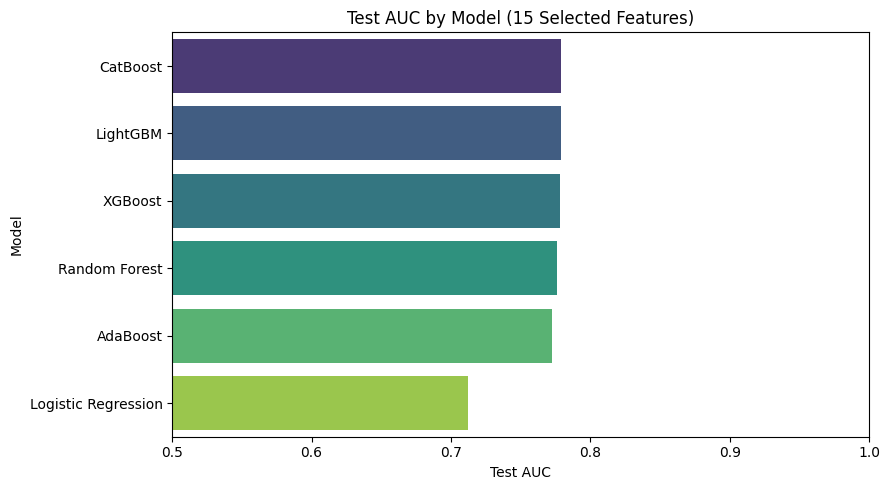

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Test AUC", y="Model", palette="viridis")
plt.title("Test AUC by Model (15 Selected Features)")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
test_pred = best_model.predict(X_test_15)

print(f"Confusion matrix for best model ({best_model_name}):")
print(confusion_matrix(y_test, test_pred))

Confusion matrix for best model (CatBoost):
[[6647  362]
 [1282  709]]


## 12. Conclusion

**Best model:** CatBoost, LightGBM, and XGBoost essentially tied for best performance
(Test AUC 0.779, 0.779, 0.779), with the differences too small to call a real winner.
Random Forest scored similarly on the test set (0.776) but overfit noticeably more
(train-test gap of 0.15 vs ~0.06 for the boosting models). Logistic Regression trailed
everything else by about 6.5 AUC points (0.713), showing it can't capture the non-linear
patterns in the payment-history features that tree-based models pick up.

**Feature selection impact on LightGBM:**

| Stage | Num Features | Train AUC | Test AUC |
|---|---|---|---|
| 23 (baseline) | 23 | 0.9184 | 0.7750 |
| After Step A | 16 | 0.9117 | 0.7725 |
| After Step B | 16 | 0.9117 | 0.7725 |
| 15 (After Step C) | 15 | 0.9105 | 0.7743 |

Cutting the feature count from 23 to 15 (a 35% reduction) barely changed Test AUC
(0.7750 → 0.7743), which means the removed features were mostly redundant rather than
useful. The correlation filter dropped seven collinear features (the `BILL_AMT2`–
`BILL_AMT6` group plus `PAY_4` and `PAY_6`); the IV filter removed nothing, since every
remaining feature still had a positive IV; and the SHAP step dropped `SEX`, the weakest
feature, to reach the final 15 — Test AUC actually ticked back up slightly at that point.
`PAY_0` (most recent repayment status) is by far the strongest predictor throughout,
more than double the importance of the next-best feature, `LIMIT_BAL`.

**Trade-offs:** The boosting models (LightGBM, XGBoost, CatBoost) give the best accuracy
but take longer to tune and are harder to interpret directly. Random Forest needed the
most care to avoid overfitting. Logistic Regression is the fastest and easiest to
interpret, at a real cost in accuracy — a reasonable choice if transparency matters more
than raw performance for a credit-decision context. Overall, reducing to 15 features
lost essentially no accuracy, so the simpler model is the practical choice here.